# 6 · The JAX physical models

Kilonovae, tidal disruption events and supernovae, re-implemented in JAX so they can be jitted,
vmapped and differentiated. These are physical models: their parameters are ejecta masses, opacities,
black-hole masses and explosion energies.

**Needs:** the `[gpu]` extra, and `source "$(whisper-cbpf-env)"` before Python starts.

**float64 is mandatory** for the TDE and every supernova — they raise at the first `predict` rather
than returning a wrong answer. Set it before the first JAX array exists, as the next cell does.

Where these differ from redback, and why, is in
[`docs/PORTING_NOTES.md`](../docs/PORTING_NOTES.md).

In [1]:
from pathlib import Path

# Works whether the notebook is run from notebooks/ or from the repository root.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "tests" / "data").is_dir())
AT2017GFO = ROOT / "tests" / "data" / "at2017gfo.csv"

# float64 must be switched on BEFORE the first JAX array exists. The TDE and every supernova
# raise without it rather than returning a wrong answer.
import jax
jax.config.update("jax_enable_x64", True)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import whisper_cbpf as wp

print("whisper_cbpf", wp.__version__, "| x64:", wp.x64_enabled())

whisper_cbpf 0.1.1 | x64: True


## They are factories, not registry entries

A band flux needs a filter set, a redshift and a luminosity distance. A guessed distance silently
rescales every fitted mass, so the models are **built for your dataset** rather than shipped
pre-bound.

In [2]:
BANDS = ["sdssg", "sdssr"]
Z, DL_CM = 0.0098, 1.23e26          # AT2017GFO: the gravitational-wave distance
DL_Z005 = wp.luminosity_distance_cm(0.05)   # Planck18, for the TDE and supernovae below

kn1 = wp.kilonova_model(BANDS, redshift=Z, dl_cm=DL_CM)
print(kn1.name)
print("parameters:", kn1.parameters)
print()
print(kn1.default_prior)

kilonova_one_jax
parameters: ['mej', 'vej', 'kappa', 'temperature_floor']

Prior({'mej': Uniform(0.01, 0.05), 'vej': Uniform(0.1, 0.5), 'kappa': Uniform(1.0, 30.0), 'temperature_floor': LogUniform(100.0, 6000.0)})


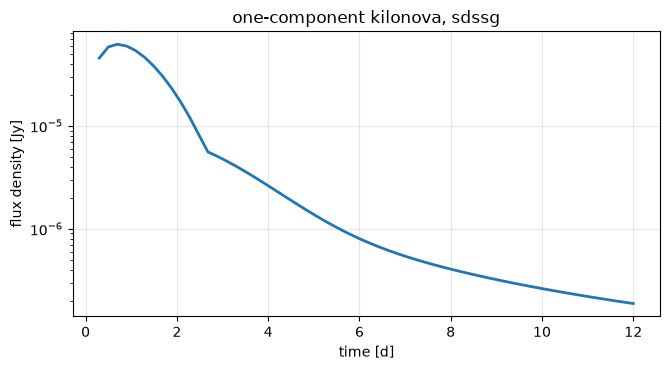

In [3]:
times = np.linspace(0.3, 12.0, 60)
bands = np.array(["sdssg"] * times.size)

p_kn = {"mej": 0.03, "vej": 0.2, "kappa": 1.0, "temperature_floor": 3000.0}
flux = kn1.predict(p_kn, times, bands)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(times, flux, lw=2)
ax.set_yscale("log"); ax.set_xlabel("time [d]"); ax.set_ylabel("flux density [Jy]")
ax.set_title("one-component kilonova, sdssg"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Multi-component kilonovae

Two and three components. Each keeps its own photosphere and temperature floor — they are separate
blackbodies whose **fluxes add**, so magnitudes of individual components must never be summed.

The default priors are **Villar et al. (2017)**, with each component given a **disjoint opacity
corridor**:

| component | `kappa` prior | Villar's fixed value |
|---|---|---|
| blue (lanthanide-poor) | U(0.1, 1.0) | 0.5 cm² g⁻¹ |
| purple (three-component only) | U(1.0, 5.0) | 3 cm² g⁻¹ |
| red (lanthanide-rich) | U(5.0, 30.0) — U(1.0, 30.0) with no purple | 10 cm² g⁻¹ |

The name of a component is cosmetic; **the opacity corridor is what makes it blue, purple or red**.
Keeping the corridors disjoint also means the components cannot swap labels, so the posterior has no
mirror modes to average over.

In [4]:
kn2 = wp.kilonova_two_model(BANDS, redshift=Z, dl_cm=DL_CM)
kn3 = wp.kilonova_three_model(BANDS, redshift=Z, dl_cm=DL_CM)

for m in (kn1, kn2, kn3):
    print(f"  {m.name:22s} {len(m.parameters):2d} params  {m.parameters}")

  kilonova_one_jax        4 params  ['mej', 'vej', 'kappa', 'temperature_floor']
  kilonova_two_jax        8 params  ['mej_blue', 'vej_blue', 'temperature_floor_blue', 'kappa_blue', 'mej_red', 'vej_red', 'temperature_floor_red', 'kappa_red']
  kilonova_three_jax     12 params  ['mej_blue', 'vej_blue', 'temperature_floor_blue', 'kappa_blue', 'mej_purple', 'vej_purple', 'temperature_floor_purple', 'kappa_purple', 'mej_red', 'vej_red', 'temperature_floor_red', 'kappa_red']


In [5]:
for name, dist in kn3.default_prior.distributions.items():
    if "kappa" in name:
        print(f"  {name:16s} {dist}")

  kappa_blue       Uniform(0.1, 1.0)
  kappa_purple     Uniform(1.0, 5.0)
  kappa_red        Uniform(5.0, 30.0)


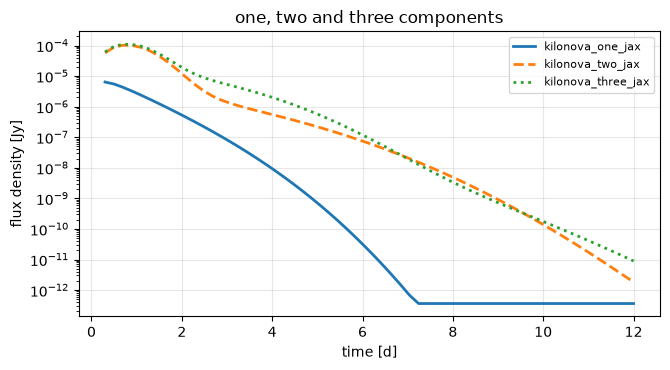

In [6]:
fig, ax = plt.subplots(figsize=(6.8, 3.8))
for m, style in ((kn1, "-"), (kn2, "--"), (kn3, ":")):
    prior = m.default_prior
    params = {k: float(np.sqrt(d.bounds[0] * d.bounds[1])) if d.bounds[0] > 0
              else float(np.mean(d.bounds)) for k, d in prior.distributions.items()}
    ax.plot(times, m.predict(params, times, bands), style, lw=2, label=m.name)
ax.set_yscale("log"); ax.set_xlabel("time [d]"); ax.set_ylabel("flux density [Jy]")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_title("one, two and three components")
plt.tight_layout(); plt.show()

## Tidal disruption events

A Gaussian rise stitched onto the Sarin & Metzger cooling envelope, which is integrated with
`lax.scan`: 500 Euler steps by default, the grid the installed redback uses (`n_time=5000` for a
finer one). The prior is redback's own; with redback 1.20 all seven parameters are free.

The TDE and the supernovae below carry redback's **constraint priors as a hard wall**: at a draw
that breaks one (here, `eta` below its minimum, `beta` above its maximum, or the stitch too far
from the peak) `predict` returns zero flux, and the JAX samplers reject the draw. So these plots
use parameters a real transient could have, not the middle of the prior box.

In [7]:
tde = wp.tde_model(BANDS, redshift=0.05, dl_cm=DL_Z005)
print(tde.name)
print("parameters:", tde.parameters)
print()
print(tde.default_prior)

tde_gaussianrise_jax
parameters: ['peak_time', 'sigma_t', 'mbh_6', 'stellar_mass', 'eta', 'alpha', 'beta']

Prior({'peak_time': LogUniform(1.0, 60.0), 'sigma_t': LogUniform(10.0, 60.0), 'mbh_6': LogUniform(0.1, 20.0), 'stellar_mass': LogUniform(0.1, 10.0), 'eta': LogUniform(0.0001, 0.1), 'alpha': LogUniform(0.1, 1.0), 'beta': Uniform(1.0, 5.0)})


passes redback's constraints: True


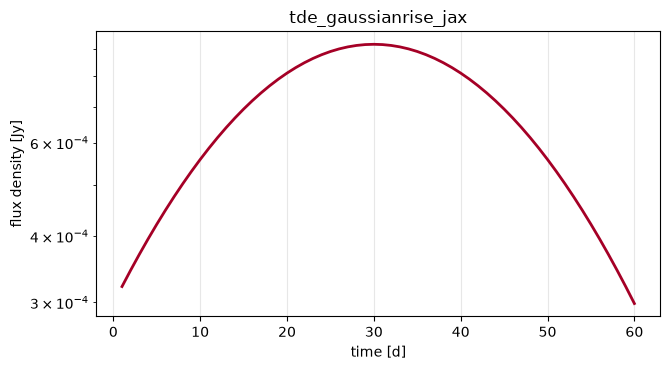

peak sdssg 16.49 mag at day 30
the envelope has cooled by day 60; after that the model returns its 40 mag floor


In [8]:
import jax.numpy as jnp

t_tde = np.linspace(1.0, 300.0, 300)
b_tde = np.array(["sdssg"] * t_tde.size)

# A 1e6 Msun black hole disrupting a Sun-like star, peaking 30 days after disruption.
p_tde = {"peak_time": 30.0, "sigma_t": 20.0, "mbh_6": 1.0, "stellar_mass": 1.0,
         "eta": 0.1, "alpha": 0.5, "beta": 1.5}
theta_tde = jnp.array([p_tde[k] for k in tde.parameters])
print("passes redback's constraints:", bool(tde.predict_jax.constraint_ok(theta_tde)))

f_tde = tde.predict(p_tde, t_tde, b_tde)
mag_tde = -2.5 * np.log10(f_tde / 3631.0)
lit = mag_tde < tde.predict_jax.mag_floor - 1e-6        # above the model's magnitude floor

fig, ax = plt.subplots(figsize=(6.8, 3.8))
ax.plot(t_tde[lit], f_tde[lit], lw=2, color="#a50026")
ax.set_yscale("log"); ax.set_xlabel("time [d]"); ax.set_ylabel("flux density [Jy]")
ax.set_title(tde.name); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"peak sdssg {mag_tde.min():.2f} mag at day {t_tde[np.argmin(mag_tde)]:.0f}")
print(f"the envelope has cooled by day {t_tde[lit].max():.0f}; after that the model returns its "
      f"{tde.predict_jax.mag_floor:g} mag floor")

## Supernovae

Twelve model names over nine engines — nickel-cobalt decay, magnetar spin-down, shock cooling, CSM
interaction, fallback accretion, and the combinations of them.

In [9]:
print(wp.supernova_models())

['arnett', 'basic_magnetar_powered', 'csm_shock_and_arnett', 'general_magnetar_slsn', 'magnetar_nickel', 'shock_cooling_and_arnett', 'slsn', 'sn_exponential_powerlaw', 'sn_fallback', 'sn_nickel_fallback', 'type_1a', 'type_1c']


In [10]:
sn = wp.supernova_model("arnett", BANDS, redshift=0.05, dl_cm=DL_Z005)
print(sn.name)
print("parameters:", sn.parameters)

arnett_jax
parameters: ['f_nickel', 'mej', 'vej', 'kappa', 'kappa_gamma', 'temperature_floor']


  arnett                   constraints passed: True           peak sdssg 18.03 mag


  basic_magnetar_powered   constraints passed: True           peak sdssg 15.58 mag


  sn_exponential_powerlaw  constraints passed: none declared  peak sdssg 20.45 mag


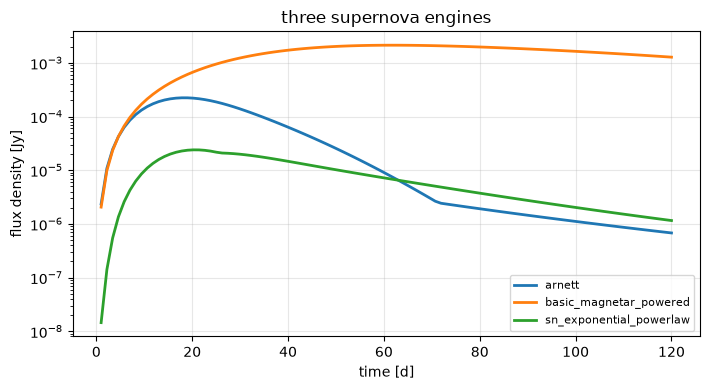

In [11]:
t_sn = np.linspace(1.0, 120.0, 100)
b_sn = np.array(["sdssg"] * t_sn.size)

SN_PARAMS = {
    # a normal Type Ia: 1.4 Msun of ejecta, 40% of it nickel
    "arnett": {"f_nickel": 0.4, "mej": 1.4, "vej": 10000.0, "kappa": 0.1,
               "kappa_gamma": 0.03, "temperature_floor": 3000.0},
    # a superluminous supernova: a 3 ms, 5e13 G magnetar inside 5 Msun of ejecta
    "basic_magnetar_powered": {"p0": 3.0, "bp": 0.5, "mass_ns": 1.4, "theta_pb": 0.5,
                               "mej": 5.0, "vej": 7000.0, "kappa": 0.1, "kappa_gamma": 0.1,
                               "temperature_floor": 5000.0},
    # an exponential rise to 1e43 erg/s at day 15, then a power-law decline
    "sn_exponential_powerlaw": {"lbol_0": 1e43, "alpha_1": 3.0, "alpha_2": 2.0, "tpeak_d": 15.0,
                                "mej": 2.0, "vej": 10000.0, "kappa": 0.1, "kappa_gamma": 0.1,
                                "temperature_floor": 5000.0},
}

fig, ax = plt.subplots(figsize=(7.2, 4))
for model, p in SN_PARAMS.items():
    m = wp.supernova_model(model, BANDS, redshift=0.05, dl_cm=DL_Z005)
    check = m.predict_jax.constraint_ok                  # None: redback declares no constraint
    physical = "none declared" if check is None else bool(check(jnp.array([p[k] for k in m.parameters])))
    f = m.predict(p, t_sn, b_sn)
    print(f"  {model:24s} constraints passed: {str(physical):14s} "
          f"peak sdssg {-2.5 * np.log10(f.max() / 3631.0):.2f} mag")
    ax.plot(t_sn, f, lw=2, label=model)
ax.set_yscale("log"); ax.set_xlabel("time [d]"); ax.set_ylabel("flux density [Jy]")
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_title("three supernova engines")
plt.tight_layout(); plt.show()

In [12]:
# At the log-midpoint of its prior, arnett's ejecta carry more kinetic energy than burning their
# nickel could release: the draw breaks the constraint and predicts zero flux.
from whisper_cbpf.models import constraints

arnett = wp.supernova_model("arnett", BANDS, redshift=0.05, dl_cm=DL_Z005)
mid = {k: float(np.sqrt(d.bounds[0] * d.bounds[1]))
       for k, d in arnett.default_prior.distributions.items()}
ratio = constraints.constraint_values("arnett", mid)["emax_constraint"]
print(f"kinetic / nuclear-burning energy at the prior's log-midpoint: {ratio:.2f} (must be < 1)")
print("max flux, constraint applied (default):", arnett.predict(mid, t_sn, b_sn).max(), "Jy")

raw = wp.supernova_model("arnett", BANDS, redshift=0.05, dl_cm=DL_Z005, constraint=None)
print(f"max flux, constraint=None             : {raw.predict(mid, t_sn, b_sn).max():.3e} Jy")

kinetic / nuclear-burning energy at the prior's log-midpoint: 2.61 (must be < 1)
max flux, constraint applied (default): 0.0 Jy


max flux, constraint=None             : 1.985e-06 Jy


## Explosion time and redshift as parameters

Built as above, a supernova sits at a known redshift and distance, on a clock that starts at the
explosion. An alert has neither. `free=["t_exp", "redshift"]` makes both ordinary parameters: the
explosion time on the light curve's own clock, and the redshift with the distance following it
(Planck18, `wp.luminosity_distance_cm`). Both are traced like any other parameter, so `jit` and
`vmap` over them compile once. `wp.compare` binds the families this way by itself (notebook 11).

In [13]:
alert_sn = wp.supernova_model(
    "arnett", ["lsstg", "lsstr"], free=["t_exp", "redshift"],
    prior=wp.Prior({"t_exp": wp.Uniform(60995.0, 61001.0, name="t_exp")}),
    redshift_prior=wp.TruncatedNormal(0.05, 0.01, 0.001, 0.3, name="redshift"))
print("parameters:", alert_sn.parameters)
print()
print(alert_sn.default_prior)

# The same supernova at two redshifts: the distance follows z, so the farther one is fainter.
p = dict(SN_PARAMS["arnett"], t_exp=61000.0)
t_obs = np.array([61010.0, 61020.0, 61040.0])
for z in (0.03, 0.06):
    mag = -2.5 * np.log10(alert_sn.predict(dict(p, redshift=z), t_obs,
                                           np.array(["lsstr"] * 3)) / 3631.0)
    print(f"z = {z}: lsstr at MJD {t_obs.astype(int).tolist()} -> {np.round(mag, 2).tolist()} mag")

parameters: ['f_nickel', 'mej', 'vej', 'kappa', 'kappa_gamma', 'temperature_floor', 't_exp', 'redshift']

Prior({'f_nickel': LogUniform(0.001, 1.0), 'mej': LogUniform(0.0001, 100.0), 'vej': LogUniform(1000.0, 100000.0), 'kappa': Uniform(0.05, 2.0), 'kappa_gamma': LogUniform(0.0001, 10000.0), 'temperature_floor': LogUniform(1000.0, 100000.0), 't_exp': Uniform(60995.0, 61001.0), 'redshift': TruncatedNormal(0.05, 0.01, 0.001, 0.3)})


z = 0.03: lsstr at MJD [61010, 61020, 61040] -> [17.49, 16.82, 17.55] mag
z = 0.06: lsstr at MJD [61010, 61020, 61040] -> [19.04, 18.35, 19.06] mag


## What float64 buys, and what happens without it

The TDE's Euler integration accumulates increments about 1e-6 of the state, which float32 cannot
resolve; the supernovae are bolometric luminosities in cgs and simply overflow float32's 3.4e38.
Both raise rather than returning a light curve of exactly `mag_floor` with finite gradients.

In [14]:
print("x64 enabled:", wp.x64_enabled())
print()
print("If it were not, tde.predict and every supernova would raise at the first call --")
print("deliberately, because the alternative is a plausible wrong answer.")

x64 enabled: True

If it were not, tde.predict and every supernova would raise at the first call --
deliberately, because the alternative is a plausible wrong answer.


## They are differentiable

This is the point of the port: `jax.grad` through the whole forward model is what NUTS needs.

In [15]:
theta0 = jnp.array([p_kn[k] for k in kn1.parameters])
band_idx = jnp.zeros(times.size, dtype=int)      # all sdssg

def total_flux(theta):
    return jnp.sum(kn1.predict_jax(theta, times, band_idx))

grad = jax.grad(total_flux)(theta0)
for name, gval in zip(kn1.parameters, grad):
    print(f"  d(sum flux)/d({name:18s}) = {float(gval):+.6e}")
print()
print("all finite:", bool(jnp.all(jnp.isfinite(grad))))

  d(sum flux)/d(mej               ) = +9.756778e-03
  d(sum flux)/d(vej               ) = -3.609678e-04
  d(sum flux)/d(kappa             ) = -5.294665e-04
  d(sum flux)/d(temperature_floor ) = +1.103617e-07

all finite: True


## Registering them

`register_*` builds the model and puts it in the registry, so `wp.fit(lc, "kilonova_one_jax", ...)`
works from then on. Re-running with a different redshift replaces the binding.

In [16]:
for fn, args in [(wp.register_kilonova, (BANDS, Z, DL_CM)),
                 (wp.register_kilonova_two, (BANDS, Z, DL_CM)),
                 (wp.register_kilonova_three, (BANDS, Z, DL_CM)),
                 (wp.register_tde, (BANDS, 0.05, DL_Z005))]:
    m = fn(*args)
    print(f"  {fn.__name__:26s} -> {m.name}")
print()
print(wp.register_supernova("arnett", BANDS, 0.05, DL_Z005).name)
print()
print("registry now:", [n for n in wp.list_models() if n.endswith("_jax")])

  register_kilonova          -> kilonova_one_jax
  register_kilonova_two      -> kilonova_two_jax
  register_kilonova_three    -> kilonova_three_jax
  register_tde               -> tde_gaussianrise_jax

arnett_jax

registry now: ['arnett_jax', 'flare_jax', 'kilonova_one_jax', 'kilonova_three_jax', 'kilonova_two_jax', 'tde_gaussianrise_jax']


## The JAX flare

`flare_jax` is the one JAX model that needs no filter set — a Gaussian rise with exponential decay,
in log-space parameters. It is the right thing to develop a GPU pipeline against, because it costs
almost nothing to evaluate.

In [17]:
fl = wp.flare_model()
print(fl.name, "|", fl.parameters)
print(fl.default_prior)

flare_jax | ['log_amp', 'log_sigma', 'log_tau', 't0']
Prior({'log_amp': Uniform(-2.0, 3.0), 'log_sigma': Uniform(-2.0, 3.0), 'log_tau': Uniform(-2.0, 4.0), 't0': Uniform(0.0, 30.0)})


## Where next

* [07 · GPU samplers](07_gpu_samplers.ipynb) — fit these models.
* [`docs/PORTING_NOTES.md`](../docs/PORTING_NOTES.md) — every deviation from redback, measured.